In [20]:
import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams['figure.dpi'] = 300

from ts_toolkit.io import clean_timeseries
from ts_toolkit.calendar import add_hour_sin_cos
from ts_toolkit.viz import plot_history_forecast
from ts_toolkit.split import three_way_split
from src.models.recursive_catboost_model import RecursiveDelayForecastModel
from ts_toolkit.metrics import daily_mae
from ts_toolkit.metrics import global_metrics
from sklearn.model_selection import TimeSeriesSplit
import numpy as np


In [2]:

from src.data_loader import fetch_frame


df = fetch_frame(
    use_cache=True,
    cache_filename="only_common_delayp90.parquet"
)

In [3]:
df = clean_timeseries(df, 'common_delay_p90')   # вместо блока 0‑3


In [12]:
# Разделяем данные
df_train, df_val, df_hold = three_way_split(df, train_ratio=0.8, val_ratio=0.19)

# ── Создание и обучение модели ─────────────────────────────────
# model = RecursiveDelayForecastModel(
#     horizon=len(df_hold), # Горизонт прогноза равен размеру hold-out
#     lags=[1, 2, 4, 96, 192, 5760],
#     roll_windows=[4, 96, 192, 1920, 2880, 4320, 5760, 8640],
# )
model = RecursiveDelayForecastModel(
    horizon=len(df_hold), # Горизонт прогноза равен размеру hold-out
    lags=[96, 192, 5760],
    roll_windows=[4, 96, 192, 1920, 2880, 4320, 5760, 8640],
)

# Обучаем модель. fit больше не возвращает датафреймы.
print("Начинаю обучение модели...")
model.fit(
    train_df=df_train, 
    target_col='common_delay_p90',
    val_df=df_val
    # feature_cols больше не нужны, модель сама создает календарные признаки
)
print("Модель успешно обучена!")
model.save("recursive_delay_model_v2") 

Начинаю обучение модели...
Модель успешно обучена!
Model saved to recursive_delay_model_v2


In [13]:
model

In [14]:
# ── Прогноз на будущее (hold-out) ──────────────────────────
# Для предсказания нам нужна история, достаточная для создания самых "длинных" признаков
history_need = max(model.lags + model.roll_windows)

# Используем только доступную историю (train + val)
# .tail() не нужен, так как _prepare_features сам разберется
df_context = pd.concat([df_train, df_val])

# 🎯 НОВЫЙ МЕТОД ПРОГНОЗА: один вызов возвращает весь горизонт
print("Делаю прогноз...")
y_pred_series = model.predict(df_hist=df_context)
print("Прогноз готов!")

Делаю прогноз...
Прогноз готов!


In [21]:
# Разделяем данные: сначала отделяем hold-out, а на остальном будем делать кросс-валидацию
hold_out_size = int(len(df) * 0.01) # Например, 1% данных под hold-out. Можешь поменять.
df_train_val = df.iloc[:-hold_out_size]
df_hold = df.iloc[-hold_out_size:]

print(f"Размер полного датасета: {len(df)}")
print(f"Размер для обучения и CV: {len(df_train_val)}")
print(f"Размер для hold-out теста: {len(df_hold)}")

Размер полного датасета: 90643
Размер для обучения и CV: 89737
Размер для hold-out теста: 906


In [23]:
# ── Кросс-валидация с TimeSeriesSplit ─────────────────────────────────
n_splits = 5 # Количество фолдов для кросс-валидации
tscv = TimeSeriesSplit(n_splits=n_splits, test_size=900)

metrics_list = []
print(f"Запускаю кросс-валидацию на {n_splits} фолдах...")

for i, (train_index, val_index) in enumerate(tscv.split(df_train_val)):
    print(f"\n--- Фолд {i+1}/{n_splits} ---")
    df_train_fold = df_train_val.iloc[train_index]
    df_val_fold = df_train_val.iloc[val_index]

    # Модель для фолда
    model_fold = RecursiveDelayForecastModel(
        horizon=len(df_val_fold), # Горизонт равен размеру валидационного сета
        lags=[96, 192, 5760],
        roll_windows=[4, 96, 192, 1920, 2880, 4320, 5760, 8640],
    )
    
    print("Начинаю обучение на фолде...")
    model_fold.fit(
        train_df=df_train_fold, 
        target_col='common_delay_p90',
        val_df=df_val_fold
    )
    print("Обучение на фолде завершено.")

    # Прогноз на валидационной части фолда
    y_pred_fold = model_fold.predict(df_hist=df_train_fold)
    y_true_fold = df_val_fold['common_delay_p90'].reindex(y_pred_fold.index).dropna()
    
    # Выравниваем y_pred_fold по индексам y_true_fold, чтобы избежать ошибок в метриках
    y_pred_fold = y_pred_fold.reindex(y_true_fold.index).dropna()
    
    if len(y_true_fold) > 0 and len(y_pred_fold) > 0:
        fold_metrics = global_metrics(y_true_fold, y_pred_fold)
        metrics_list.append(fold_metrics)
        print(f"Метрики на фолде {i+1}: MAE={fold_metrics['MAE']:.1f}, RMSE={fold_metrics['RMSE']:.1f}, MAPE={fold_metrics['MAPE']:.2f}%")
    else:
        print(f"На фолде {i+1} не получилось посчитать метрики (нет пересечения данных).")


# Усредненные метрики по кросс-валидации
if metrics_list:
    avg_metrics = {key: np.mean([m[key] for m in metrics_list]) for key in metrics_list[0]}
    print("\n--- Результаты кросс-валидации (средние) ---")
    print(f"CV Avg • MAE={avg_metrics['MAE']:.1f}  RMSE={avg_metrics['RMSE']:.1f}  MAPE={avg_metrics['MAPE']:.2f}%")
else:
    print("\nНе удалось собрать метрики ни на одном из фолдов.")


# ── Обучение финальной модели на всех данных (train+val) ───────────────
print("\nНачинаю обучение финальной модели на всех данных train+val...")
final_model = RecursiveDelayForecastModel(
    horizon=len(df_hold), # Горизонт прогноза равен размеру hold-out
    lags=[96, 192, 5760],
    roll_windows=[4, 96, 192, 1920, 2880, 4320, 5760, 8640],
)

# Обучаем модель. val_df не передаем, т.к. используем все данные для обучения
final_model.fit(
    train_df=df_train_val, 
    target_col='common_delay_p90'
)
print("Финальная модель успешно обучена!")
final_model.save("recursive_delay_model_v2_cv")

Запускаю кросс-валидацию на 5 фолдах...

--- Фолд 1/5 ---
Начинаю обучение на фолде...
Обучение на фолде завершено.
Метрики на фолде 1: MAE=651.0, RMSE=874.0, MAPE=21.43%

--- Фолд 2/5 ---
Начинаю обучение на фолде...
Обучение на фолде завершено.
Метрики на фолде 2: MAE=1411.6, RMSE=1651.6, MAPE=59.83%

--- Фолд 3/5 ---
Начинаю обучение на фолде...
Обучение на фолде завершено.
Метрики на фолде 3: MAE=935.8, RMSE=1314.1, MAPE=30.44%

--- Фолд 4/5 ---
Начинаю обучение на фолде...
Обучение на фолде завершено.
Метрики на фолде 4: MAE=973.2, RMSE=1165.7, MAPE=42.54%

--- Фолд 5/5 ---
Начинаю обучение на фолде...
Обучение на фолде завершено.
Метрики на фолде 5: MAE=1477.1, RMSE=1633.6, MAPE=53.71%

--- Результаты кросс-валидации (средние) ---
CV Avg • MAE=1089.7  RMSE=1327.8  MAPE=41.59%

Начинаю обучение финальной модели на всех данных train+val...
Финальная модель успешно обучена!
Model saved to recursive_delay_model_v2_cv


In [24]:
# ── Прогноз на будущее (hold-out) ──────────────────────────
print("\nДелаю прогноз на hold-out сете...")

# Для предсказания используем всю историю до hold-out (df_train_val)
# Модель сама возьмет хвост нужной длины
y_pred_series = final_model.predict(df_hist=df_train_val)

print("Прогноз готов!")


Делаю прогноз на hold-out сете...
Прогноз готов!


In [25]:
# Подготавливаем данные для сравнения
pred_idx = y_pred_series.index
y_true = df_hold['common_delay_p90'].reindex(y_pred_series.index).dropna()
y_pred = y_pred_series.reindex(y_true.index).dropna() # Убедимся, что все выровнено

print(f"Длина прогноза: {len(y_pred)}, Длина реальных данных: {len(y_true)}")

Длина прогноза: 906, Длина реальных данных: 906


Blind 24-h test • MAE=1054.1  RMSE=1227.9  MAPE=30.50%  on 906 valid points


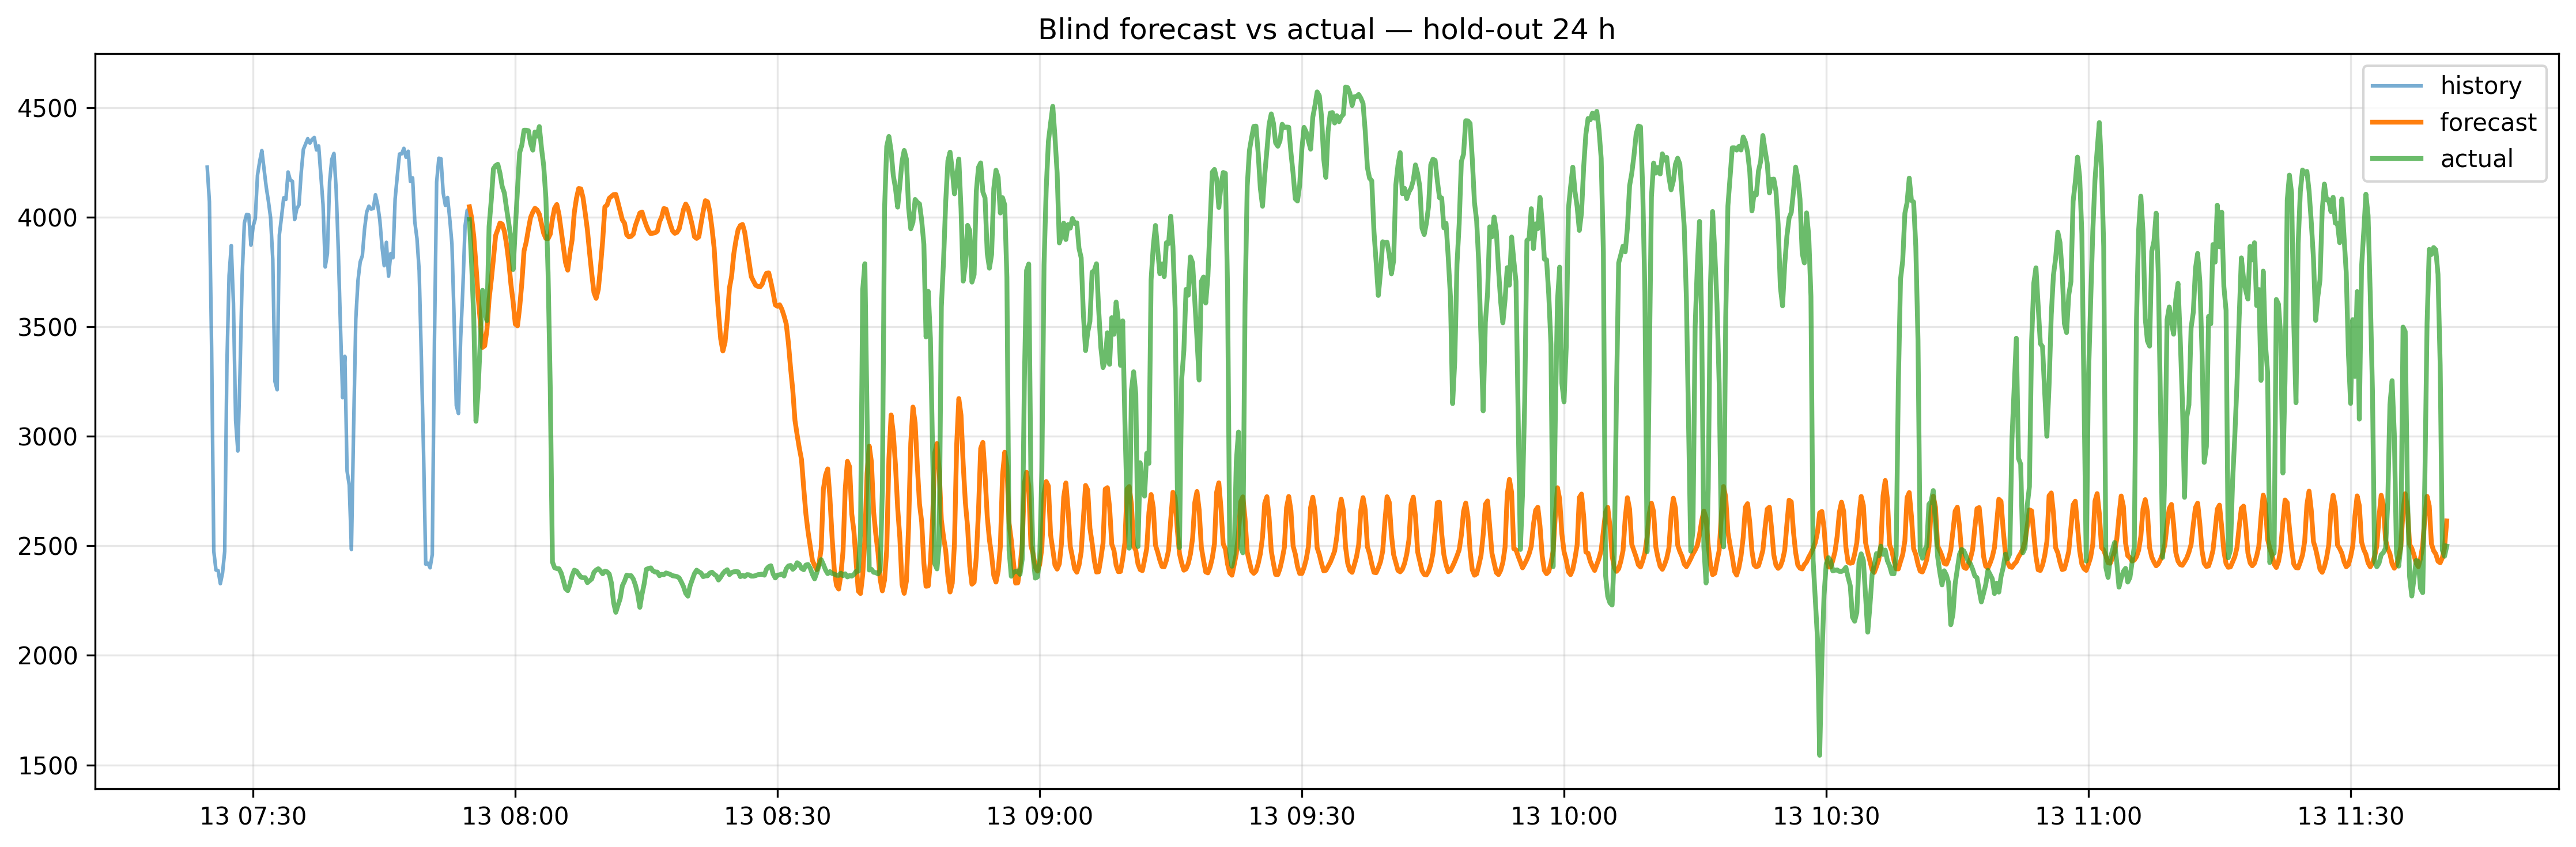

In [26]:
# y_true и y_pred уже созданы в предыдущей ячейке

metrics = global_metrics(y_true, y_pred)
print(f"Blind 24-h test • MAE={metrics['MAE']:.1f}  RMSE={metrics['RMSE']:.1f}  MAPE={metrics['MAPE']:.2f}%  "
      f"on {len(y_true)} valid points")

# ── график: история 3 сут + прогноз vs факт ──
# hist_start = pred_idx[0] - pd.Timedelta(hours=1)
hist_start = pred_idx[0] - pd.Timedelta(minutes=30)
plot_history_forecast(
    history  = df.loc[hist_start:pred_idx[0], 'common_delay_p90'],
    forecast = pd.Series(y_pred, index=pred_idx),
    actual   = y_true,
    title    = 'Blind forecast vs actual — hold-out 24 h'
)

<Axes: >

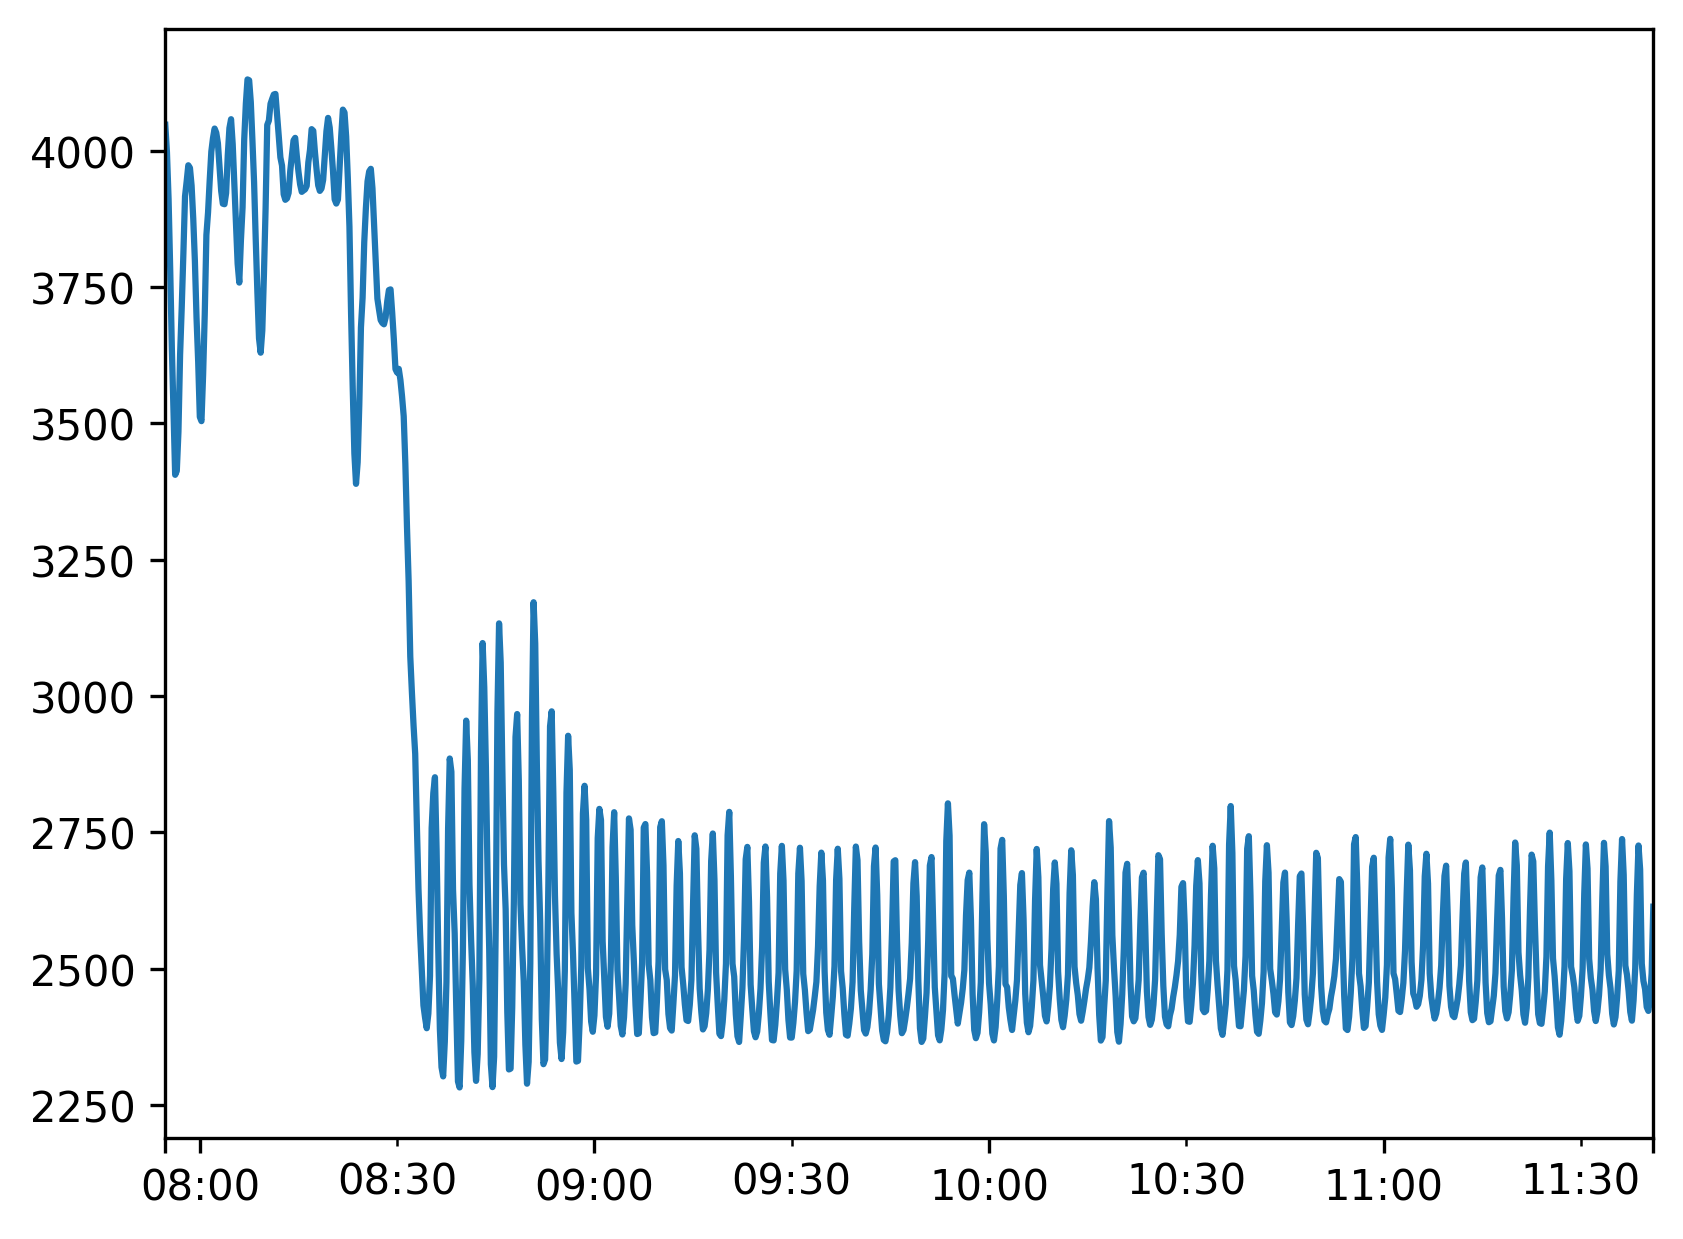

In [27]:
pd.Series(y_pred, index=pred_idx).plot()



*** Hold-out metrics ***
            value
MAE   1054.123845
RMSE  1227.872794
MAPE    30.497492

MAE by day:
        index          MAE
0  2025-05-13  1054.123845


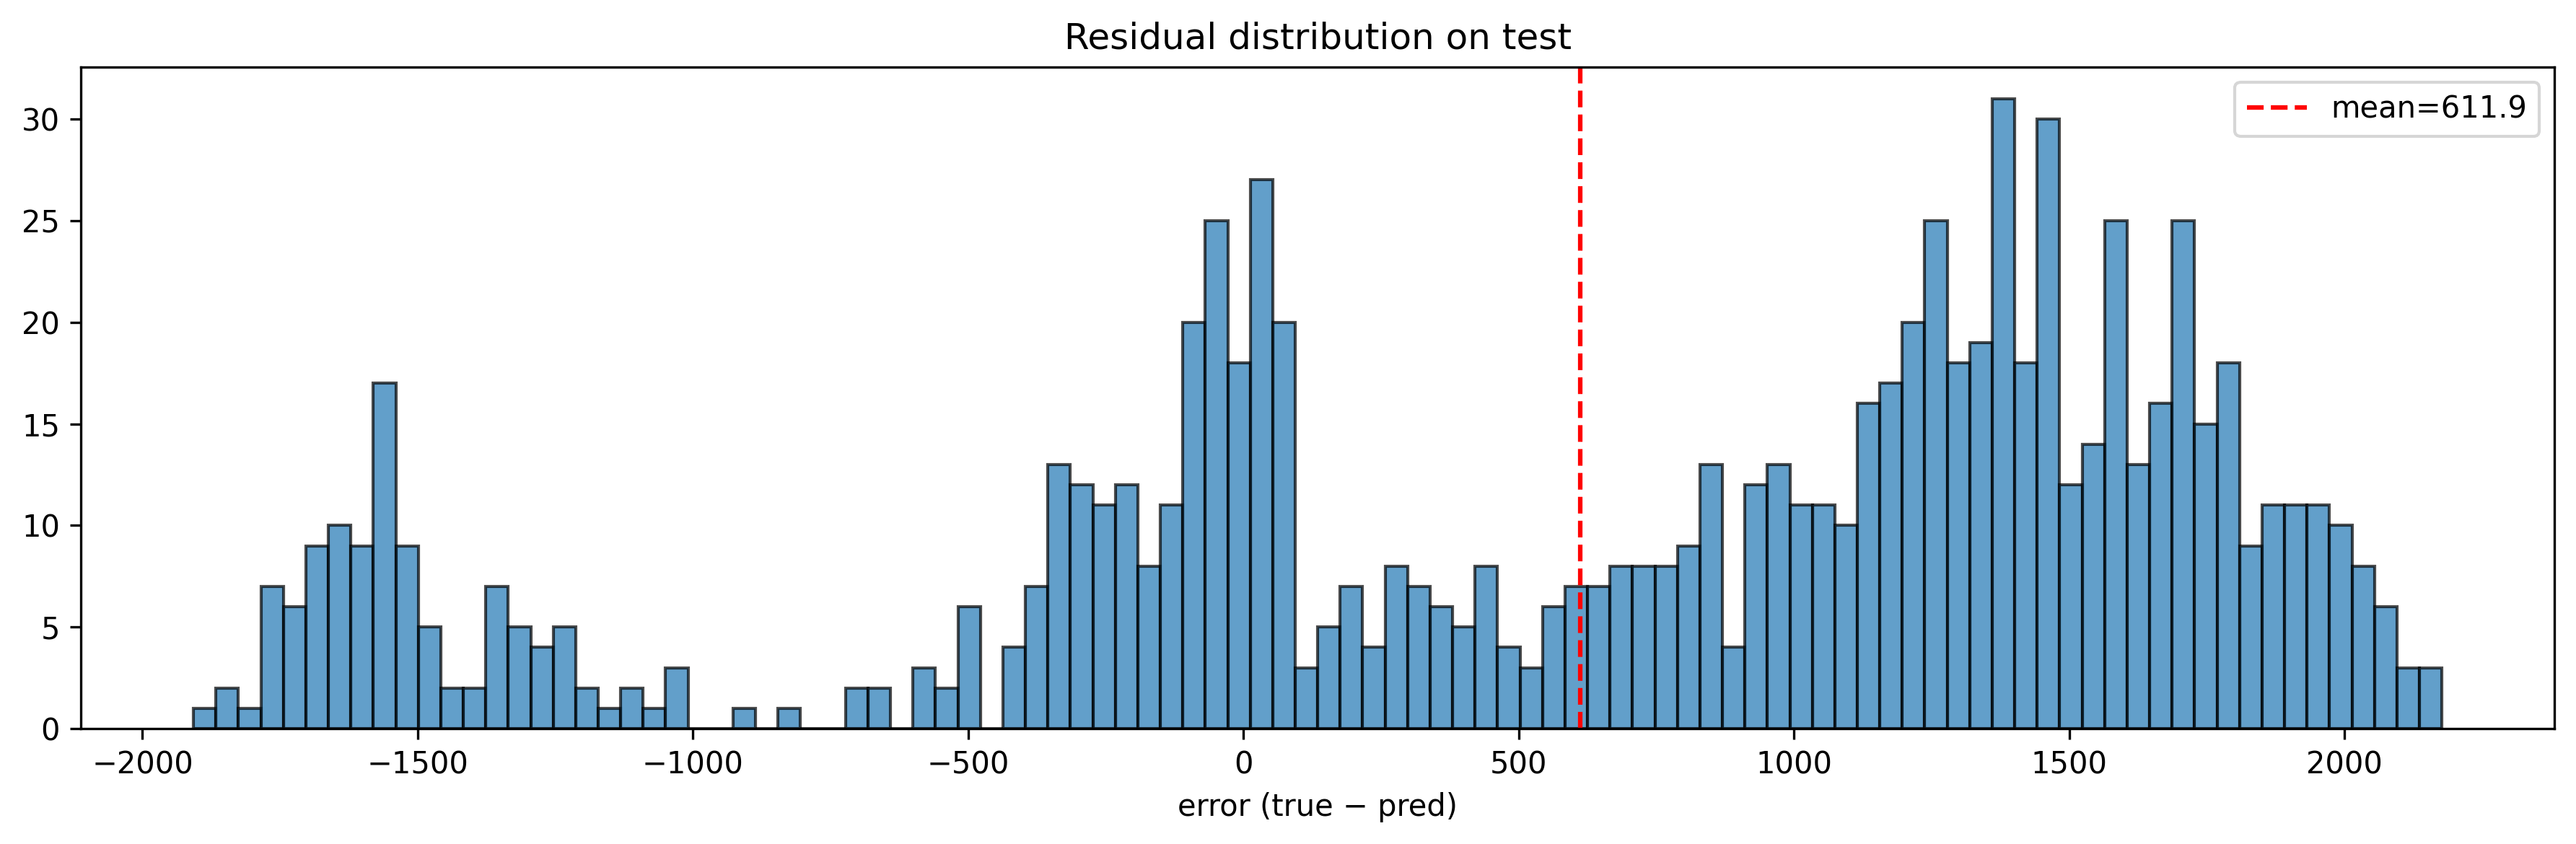

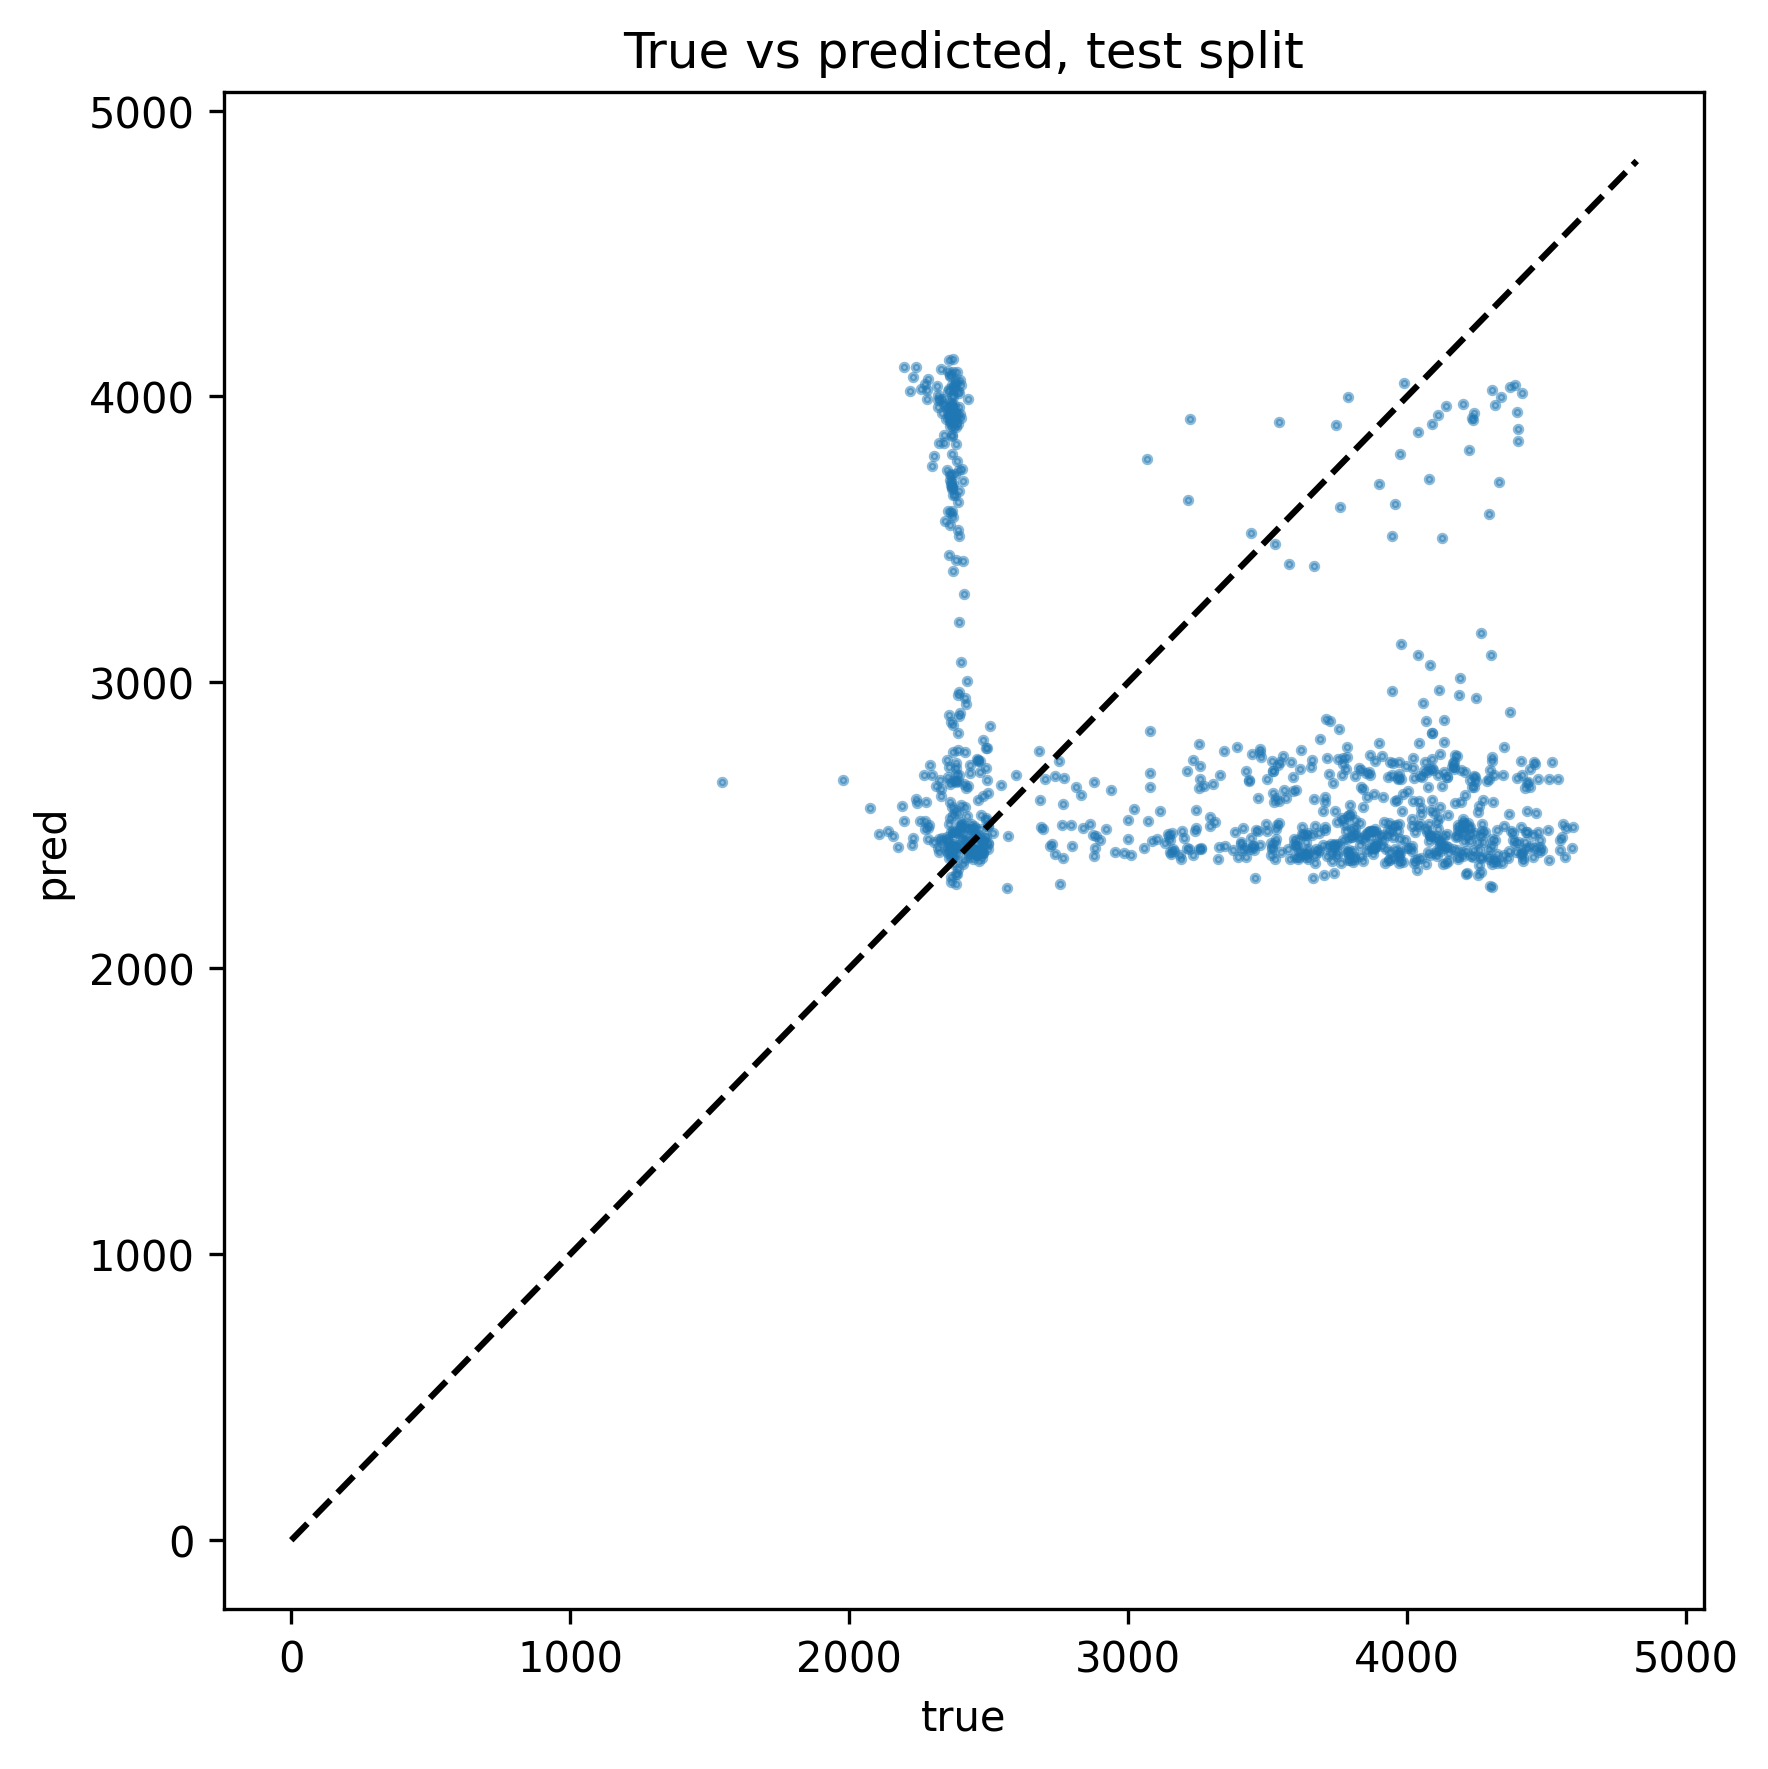

In [28]:
resid = y_true - y_pred


# ---------------------------------------------------
# 2.2  сводные метрики
# ---------------------------------------------------
metrics = global_metrics(y_true, y_pred)
metrics_df = pd.DataFrame([metrics]).T.rename(columns={0: "value"})
print("\n*** Hold-out metrics ***")
print(metrics_df)

# ---------------------------------------------------
# 2.3  метрики по суткам
# ---------------------------------------------------
daily_mae_result = daily_mae(y_true, y_pred)
print("\nMAE by day:")
print(daily_mae_result.tail())

# ---------------------------------------------------
# 2.4  распределение ошибок
# ---------------------------------------------------
plt.figure(figsize=(12,4))
plt.hist(resid, bins=100, alpha=.7, edgecolor='black')
plt.axvline(resid.mean(), color='r', linestyle='--', label=f"mean={resid.mean():.1f}")
plt.title("Residual distribution on test")
plt.xlabel("error (true − pred)")
plt.legend(); plt.tight_layout(); plt.show()

# ---------------------------------------------------
# 2.5  true vs pred scatter
# ---------------------------------------------------
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, s=3, alpha=0.5)
lim = [0, max(y_true.max(), y_pred.max())*1.05]
plt.plot(lim, lim, 'k--')
plt.xlabel("true"); plt.ylabel("pred")
plt.title("True vs predicted, test split")
plt.tight_layout(); plt.show()


                        feature  importance
0   f_target_ewm_mean_alpha_0_3   50.091407
1           f_target_roll_max_4   15.021339
2               f_target_diff_2    9.557235
3               f_target_diff_1    6.008806
4   f_target_ewm_mean_alpha_0_1    3.850742
5    f_target_diff_1_roll_std_4    3.025092
6               f_target_diff_4    2.962743
7       common_delay_p90_roll_4    2.566304
8          f_target_roll_max_12    1.970144
9      common_delay_p90_roll_96    1.271900
10    common_delay_p90_roll_192    0.851245
11             f_target_diff_96    0.547164
12     common_delay_p90_lag_192    0.397977
13   common_delay_p90_roll_2880    0.298647
14    common_delay_p90_lag_5760    0.241348
15   common_delay_p90_roll_1920    0.194547
16      common_delay_p90_lag_96    0.183889
17                          dow    0.161553
18                         hour    0.159186
19   common_delay_p90_roll_4320    0.145145


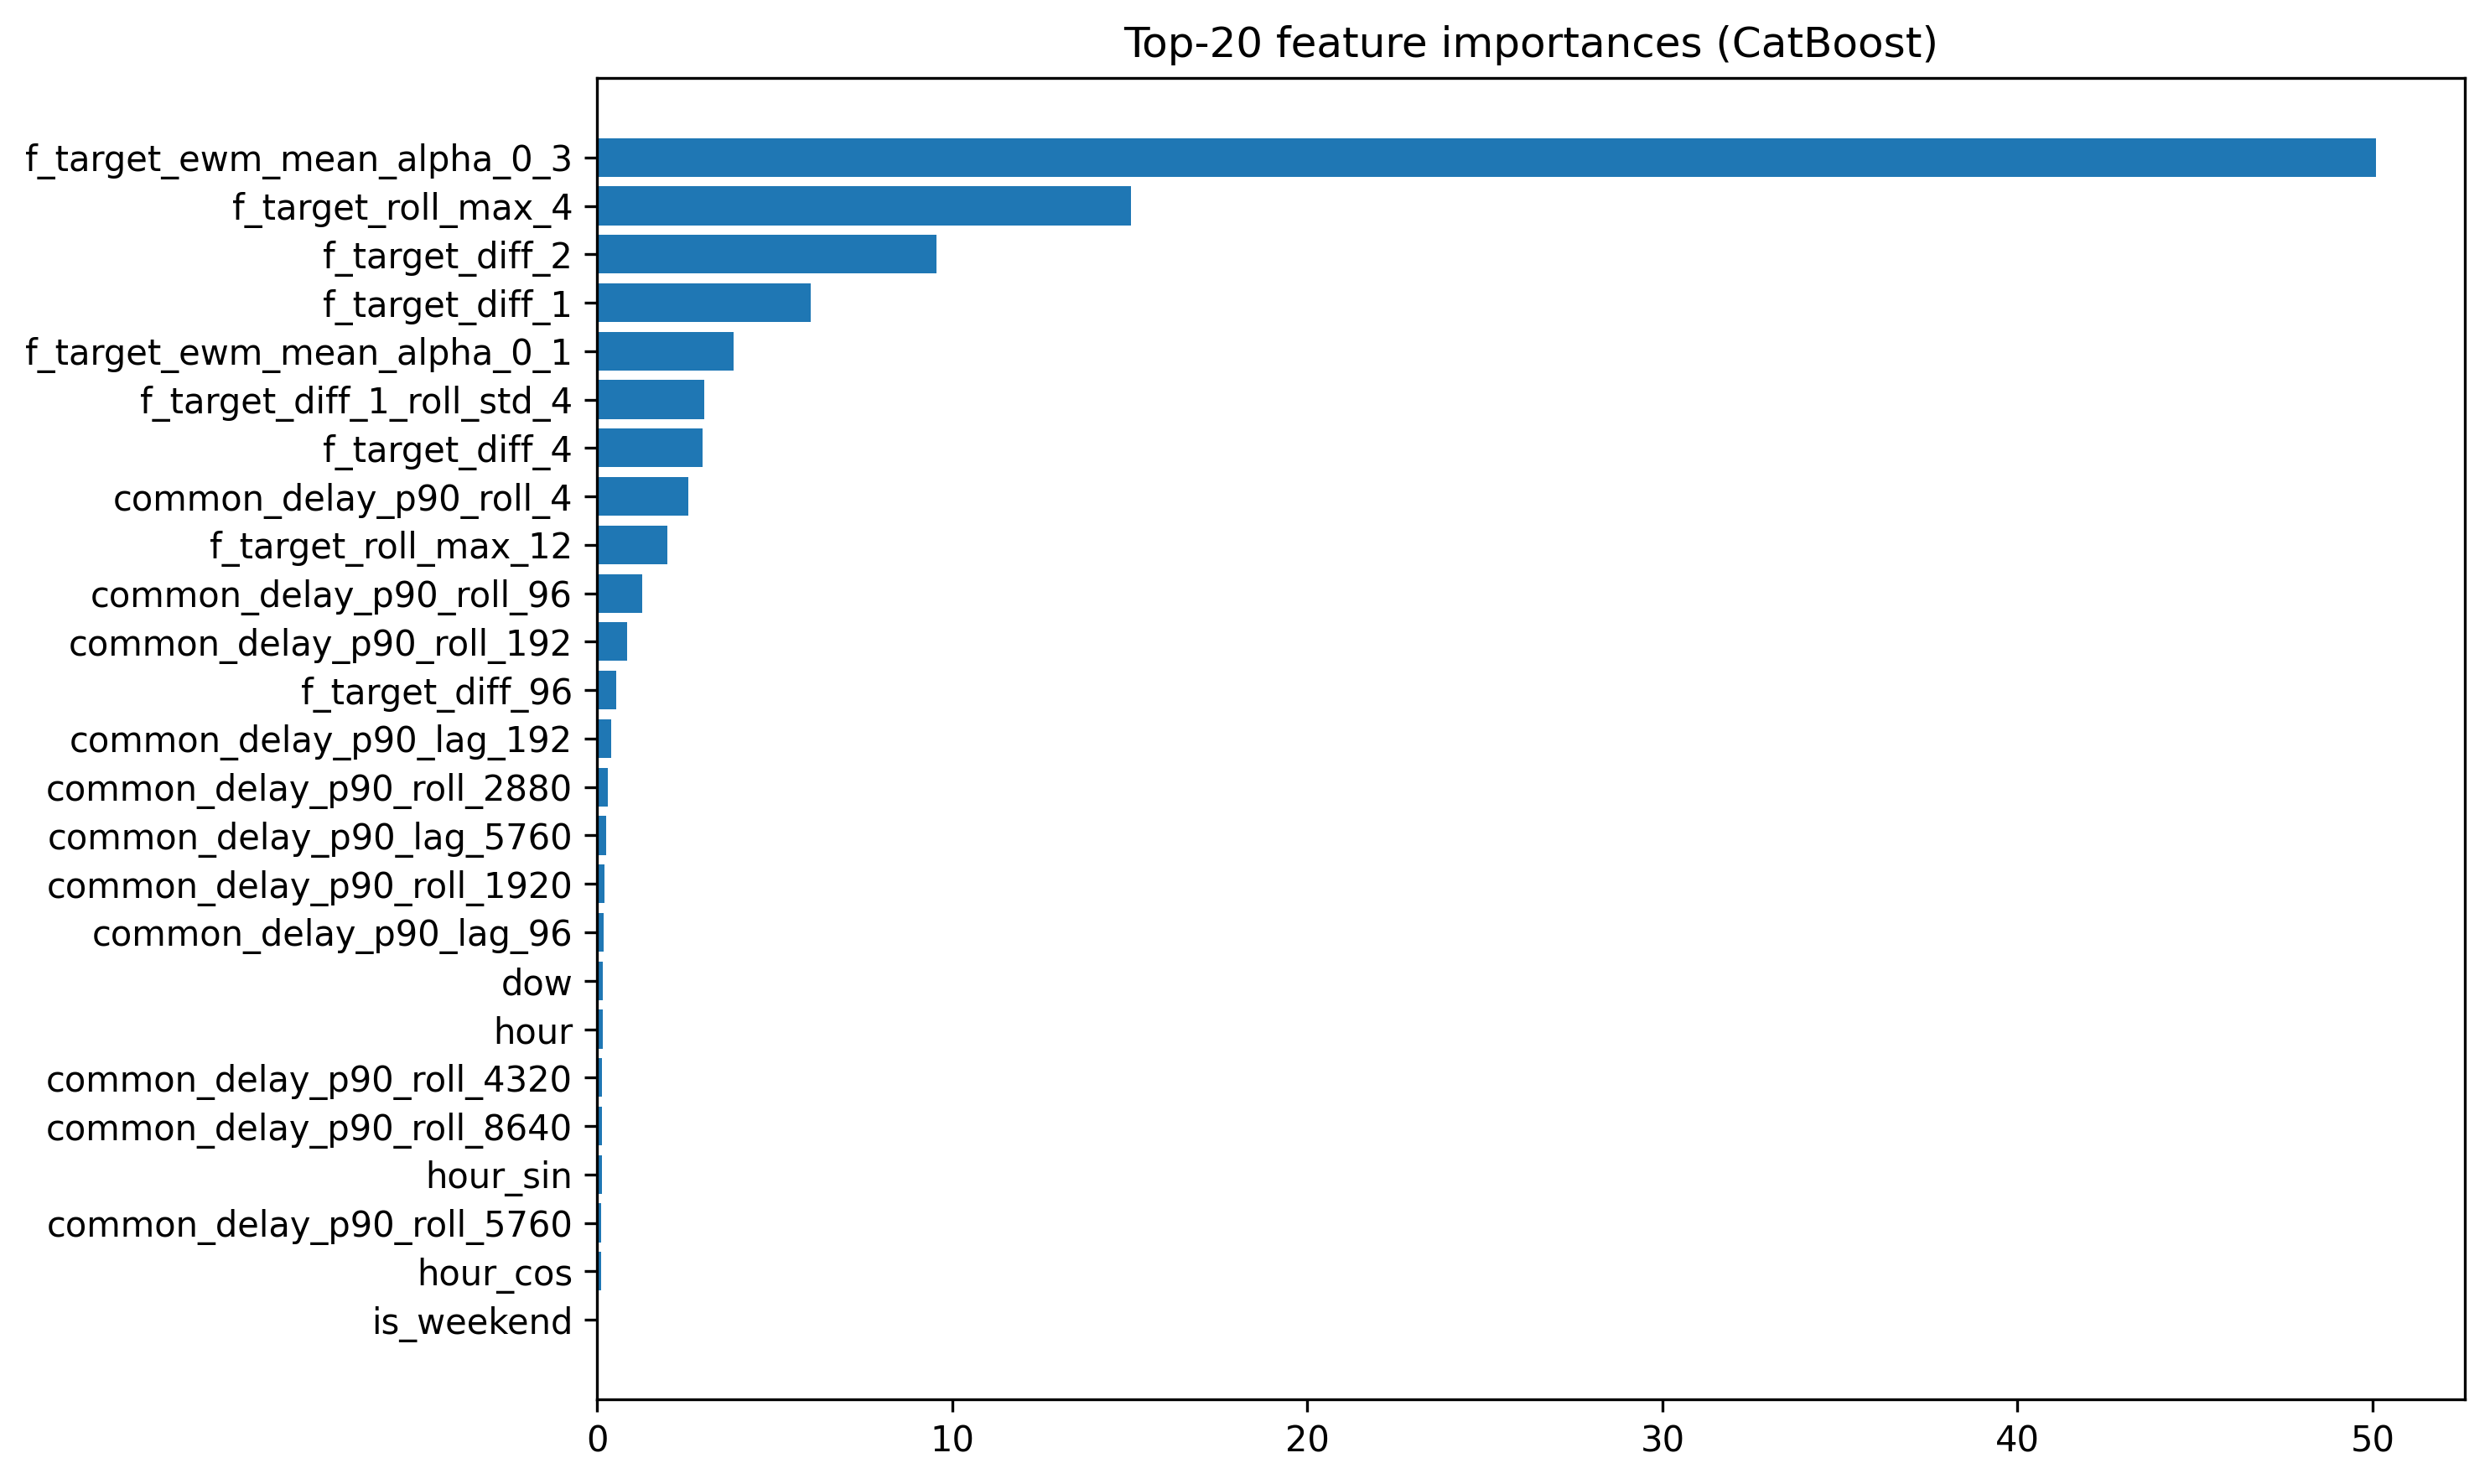

In [29]:
# model = loaded_model
feat_names = model.model.feature_names_        # ← то, что CatBoost запомнил
importances = model.model.get_feature_importance(type='FeatureImportance')

# в один датафрейм
imp_df = (pd.DataFrame({"feature": feat_names,
                        "importance": importances})
            .sort_values(by="importance", ascending=False)
            .reset_index(drop=True))

print(imp_df.head(20))
# ---------------------------------------------------
#  топ-20 на графике
# ---------------------------------------------------
plt.figure(figsize=(10,6))
plt.barh(imp_df.feature[::-1],
         imp_df.importance[::-1])
# plt.barh(imp_df.feature.head(20)[::-1],
#          imp_df.importance.head(20)[::-1])
plt.title("Top-20 feature importances (CatBoost)")
plt.tight_layout(); plt.show()
